In [1]:
import pandas as pd

In [2]:
try:
    dataset = pd.read_excel("student_final_cgpa_dataset.xlsx")
except FileNotFoundError:
    print("File not found")

In [3]:
dataset.head()

,Student_ID,Age,Mid_Term,Attendance,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Per_Week,Final_CGPA,Quiz,Assignment,Gender_Male,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology,Risk_Level
0,ID00001,20,73.5,83.9,4.4,2.65,9.1,8,2.78,7.4,7.2,True,False,False,True,False,False,Safe
1,ID00002,24,92.9,80.7,4.0,3.58,4.0,4,3.76,9.3,9.7,False,False,False,False,False,False,High Performer
2,ID00003,20,98.9,91.5,3.9,3.29,6.7,4,3.75,10.0,9.0,False,False,False,False,True,False,High Performer
3,ID00004,23,100.0,73.9,8.8,3.48,4.0,6,3.69,10.0,9.6,False,False,False,True,False,False,High Performer
4,ID00005,21,56.6,79.8,2.2,2.66,8.7,6,2.34,5.6,6.7,True,False,True,False,False,False,At Risk


In [12]:
dataset = dataset.drop(["Student_ID"] , axis=1)

In [13]:
X = dataset.drop(["Final_CGPA","Risk_Level"],axis=1)
y = dataset["Risk_Level"]

In [14]:
X

,Age,Mid_Term,Attendance,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Per_Week,Quiz,Assignment,Gender_Male,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology
0,20,73.5,83.9,4.4,2.65,9.1,8,7.4,7.2,True,False,False,True,False,False
1,24,92.9,80.7,4.0,3.58,4.0,4,9.3,9.7,False,False,False,False,False,False
2,20,98.9,91.5,3.9,3.29,6.7,4,10.0,9.0,False,False,False,False,True,False
3,23,100.0,73.9,8.8,3.48,4.0,6,10.0,9.6,False,False,False,True,False,False
4,21,56.6,79.8,2.2,2.66,8.7,6,5.6,6.7,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,23,82.4,83.9,2.4,3.21,7.5,8,8.2,9.4,False,False,False,False,True,False
4996,20,98.2,82.8,7.2,3.12,7.6,7,10.0,8.8,True,False,True,False,False,False
4997,19,100.0,92.2,13.5,3.55,6.3,6,10.0,10.0,True,False,False,True,False,False
4998,22,79.7,100.0,2.4,2.86,7.0,6,8.1,8.1,False,True,False,False,False,False


In [15]:
y

0                 Safe
1       High Performer
2       High Performer
3       High Performer
4              At Risk
             ...      
4995              Safe
4996    High Performer
4997    High Performer
4998              Safe
4999              Safe
Name: Risk_Level, Length: 5000, dtype: object

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [17]:
y = le.fit_transform(y)

In [43]:
y[:10]

array([2, 1, 1, 1, 0, 0, 2, 1, 1, 2])

In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test , y_train , y_test = train_test_split(
        X,y,
        test_size=0.2,
        random_state=42
)

In [23]:
X_train =  sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [24]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [26]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [29]:
D_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [31]:
print("Accurecy: ", accuracy_score(y_test,D_pred))

Accurecy:  0.872


In [33]:
print(classification_report(y_test,D_pred))

              precision    recall  f1-score   support

           0       0.82      0.67      0.74        91
           1       0.92      0.86      0.89       398
           2       0.85      0.92      0.88       511

    accuracy                           0.87      1000
   macro avg       0.86      0.82      0.84      1000
weighted avg       0.87      0.87      0.87      1000



In [34]:
confusion_matrix(y_test,D_pred)

array([[ 61,   0,  30],
       [  0, 342,  56],
       [ 13,  29, 469]])

In [35]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: >

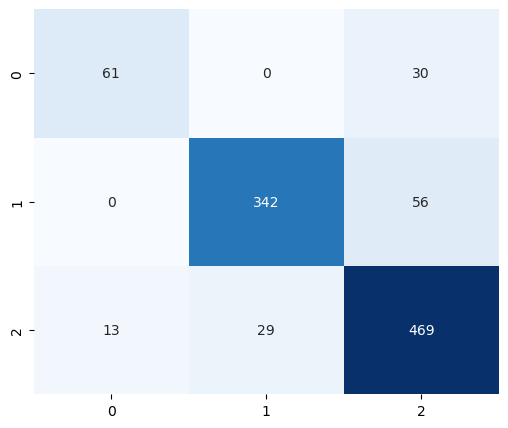

In [36]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,D_pred), annot=True , fmt='d',cmap='Blues',cbar=False)